In [129]:
# Needed if running on Colab, comment out if in local environment!
!pip3 install open-spiel
!pip3 install torch

Python(45925) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Python(45926) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [130]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from go_search_problem import GoProblem, GoState
from heuristic_go_problems import GoProblemLearnedHeuristic, GoProblemSimpleHeuristic
from agents import GreedyAgent, RandomAgent, AlphaBetaAgent
import matplotlib.pyplot as plt
from tqdm import tqdm
from game_runner import GameRunner
import pickle

torch.set_default_tensor_type(torch.FloatTensor)

In [131]:
def load_dataset(path: str):
    with open(path, 'rb') as f:
        dataset = pickle.load(f)
    return dataset

# We've provided a dataset with pyspiel and without (i.e., pygo)
# dataset_5x5 = load_dataset('dataset_5x5.pkl')
dataset_5x5 = load_dataset('dataset_5x5_pygo.pkl')

In [132]:
def save_model(path: str, model):
    """
    Save model to a file
    Input:
        path: path to save model to
        model: Pytorch model to save
    """
    torch.save({
        'model_state_dict': model.state_dict(),
    }, path)

def load_model(path: str, model):
    """
    Load model from file

    Note: you still need to provide a model (with the same architecture as the saved model))

    Input:
        path: path to load model from
        model: Pytorch model to load
    Output:
        model: Pytorch model loaded from file
    """
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

# Task 1: Convert GameState to Features

In [133]:
def get_features(game_state):
    """
    Map a game state to a list of features.
    
    Handles both GoState objects and dictionary representations.
    
    Input:
        game_state: GoState or dict to encode into features
    Output:
        features: list of features
    """
    # Handle dictionary state (from pygo)
    if isinstance(game_state, dict):
        # Extract board - it's a 4-channel array (channels, size, size)
        board = game_state.get('board')
        if isinstance(board, np.ndarray):
            board_size = board.shape[1] if len(board.shape) >= 2 else 5
        else:
            board_size = 5
        
        # Build feature array from dictionary
        features = []
        
        # Get the 4 channels from the board array
        # Channel 0: black stones, Channel 1: white stones, Channel 2: empty, Channel 3: player to move
        if isinstance(board, np.ndarray) and len(board.shape) == 3:
            # board shape is (4, size, size)
            black_channel = board[0].flatten()
            white_channel = board[1].flatten()
            empty_channel = board[2].flatten()
            player_channel = board[3].flatten()
            
            # Use the channels directly
            black_pieces = black_channel
            white_pieces = white_channel
            empty_spaces = empty_channel
            player_to_move_val = float(player_channel[0])
        else:
            # Fallback: create from coordinate lists
            black_pieces = np.zeros(board_size * board_size)
            white_pieces = np.zeros(board_size * board_size)
            empty_spaces = np.zeros(board_size * board_size)
            player_to_move_val = float(game_state.get('player_to_move', 0))
            
            # Use coordinate lists if available
            black_coords = game_state.get('black_pieces', [])
            white_coords = game_state.get('white_pieces', [])
            for coord in black_coords:
                if len(coord) == 2:
                    y, x = coord
                    black_pieces[y * board_size + x] = 1
            for coord in white_coords:
                if len(coord) == 2:
                    y, x = coord
                    white_pieces[y * board_size + x] = 1
            for i in range(board_size * board_size):
                if black_pieces[i] == 0 and white_pieces[i] == 0:
                    empty_spaces[i] = 1
        
        # Add board channels
        features.extend([float(x) for x in black_pieces])
        features.extend([float(x) for x in white_pieces])
        features.extend([float(x) for x in empty_spaces])
        
        # Player to move
        features.append(player_to_move_val)
        
        # Stone count difference (normalized)
        num_black = np.sum(black_pieces)
        num_white = np.sum(white_pieces)
        stone_diff = (num_black - num_white) / (board_size * board_size)
        features.append(float(stone_diff))
        
        # Liberty counts (simplified)
        black_liberties = 0
        white_liberties = 0
        for y in range(board_size):
            for x in range(board_size):
                idx = y * board_size + x
                if black_pieces[idx] == 1:
                    if y > 0 and empty_spaces[(y-1) * board_size + x] == 1:
                        black_liberties += 1
                    if y < board_size - 1 and empty_spaces[(y+1) * board_size + x] == 1:
                        black_liberties += 1
                    if x > 0 and empty_spaces[y * board_size + (x-1)] == 1:
                        black_liberties += 1
                    if x < board_size - 1 and empty_spaces[y * board_size + (x+1)] == 1:
                        black_liberties += 1
                elif white_pieces[idx] == 1:
                    if y > 0 and empty_spaces[(y-1) * board_size + x] == 1:
                        white_liberties += 1
                    if y < board_size - 1 and empty_spaces[(y+1) * board_size + x] == 1:
                        white_liberties += 1
                    if x > 0 and empty_spaces[y * board_size + (x-1)] == 1:
                        white_liberties += 1
                    if x < board_size - 1 and empty_spaces[y * board_size + (x+1)] == 1:
                        white_liberties += 1
        
        black_liberties_feat = black_liberties / (board_size * board_size * 4) if board_size > 0 else 0
        white_liberties_feat = white_liberties / (board_size * board_size * 4) if board_size > 0 else 0
        liberty_diff = black_liberties_feat - white_liberties_feat
        features.append(float(liberty_diff))
        
        # Center control
        center = board_size // 2
        center_control_black = 0.0
        center_control_white = 0.0
        for y in range(board_size):
            for x in range(board_size):
                dist_to_center = abs(y - center) + abs(x - center)
                weight = 1.0 / (dist_to_center + 1)
                idx = y * board_size + x
                if black_pieces[idx] == 1:
                    center_control_black += weight
                elif white_pieces[idx] == 1:
                    center_control_white += weight
        
        center_control_black = center_control_black / (board_size * board_size) if board_size > 0 else 0
        center_control_white = center_control_white / (board_size * board_size) if board_size > 0 else 0
        features.append(float(center_control_black))
        features.append(float(center_control_white))
        
        return features
    
    # Handle GoState object (original code)
    board_size = game_state.size
    board = game_state.get_board()  # Shape: (4, size, size)
    
    black_pieces = board[0].flatten()
    white_pieces = board[1].flatten()
    empty_spaces = board[2].flatten()
    player_to_move = [board[3][0][0]]
    
    num_black = np.sum(black_pieces)
    num_white = np.sum(white_pieces)
    stone_diff = (num_black - num_white) / (board_size * board_size)
    
    black_liberties = 0
    white_liberties = 0
    for y in range(board_size):
        for x in range(board_size):
            idx = y * board_size + x
            if black_pieces[idx] == 1:
                if y > 0 and empty_spaces[(y-1) * board_size + x] == 1:
                    black_liberties += 1
                if y < board_size - 1 and empty_spaces[(y+1) * board_size + x] == 1:
                    black_liberties += 1
                if x > 0 and empty_spaces[y * board_size + (x-1)] == 1:
                    black_liberties += 1
                if x < board_size - 1 and empty_spaces[y * board_size + (x+1)] == 1:
                    black_liberties += 1
            elif white_pieces[idx] == 1:
                if y > 0 and empty_spaces[(y-1) * board_size + x] == 1:
                    white_liberties += 1
                if y < board_size - 1 and empty_spaces[(y+1) * board_size + x] == 1:
                    white_liberties += 1
                if x > 0 and empty_spaces[y * board_size + (x-1)] == 1:
                    white_liberties += 1
                if x < board_size - 1 and empty_spaces[y * board_size + (x+1)] == 1:
                    white_liberties += 1
    
    black_liberties_feat = black_liberties / (board_size * board_size * 4)
    white_liberties_feat = white_liberties / (board_size * board_size * 4)
    liberty_diff = black_liberties_feat - white_liberties_feat
    
    center = board_size // 2
    center_control_black = 0.0
    center_control_white = 0.0
    for y in range(board_size):
        for x in range(board_size):
            dist_to_center = abs(y - center) + abs(x - center)
            weight = 1.0 / (dist_to_center + 1)
            idx = y * board_size + x
            if black_pieces[idx] == 1:
                center_control_black += weight
            elif white_pieces[idx] == 1:
                center_control_white += weight
    
    center_control_black = center_control_black / (board_size * board_size)
    center_control_white = center_control_white / (board_size * board_size)
    
    features = []
    features.extend([float(x) for x in black_pieces])
    features.extend([float(x) for x in white_pieces])
    features.extend([float(x) for x in empty_spaces])
    features.extend(player_to_move)
    features.append(float(stone_diff))
    features.append(float(liberty_diff))
    features.append(float(center_control_black))
    features.append(float(center_control_white))
    
    return features


# Test the fixed function
print("Testing get_features...")
data_point = dataset_5x5[0]
features = get_features(data_point[0])
action = data_point[1]
result = data_point[2]
print(f"Features length: {len(features)}")
print(f"Action #: {action}")
print(f"Game Result: {result}")
print(f"First 10 features: {features[:10]}")

Testing get_features...
Features length: 80
Action #: 1
Game Result: -1.0
First 10 features: [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [134]:
# Print information about first data point to understand structure
data_point = dataset_5x5[0]
print("Type of data_point[0]:", type(data_point[0]))
print("Keys in dict:", data_point[0].keys() if isinstance(data_point[0], dict) else "Not a dict")
print("Data point structure:", data_point)

# Check if it's a tuple with different structure
if isinstance(data_point, tuple):
    print(f"Tuple length: {len(data_point)}")
    for i, item in enumerate(data_point):
        print(f"  Item {i} type: {type(item)}")

Type of data_point[0]: <class 'dict'>
Keys in dict: dict_keys(['board', 'size', 'player_to_move', 'is_terminal', 'legal_actions', 'black_pieces', 'white_pieces'])
Data point structure: ({'board': array([[[0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.]],

       [[1., 1., 0., 1., 1.],
        [1., 1., 0., 1., 1.],
        [1., 1., 0., 0., 1.],
        [1., 1., 1., 1., 0.],
        [1., 0., 0., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]]), 'size': 5, 'player_to_move': 1, 'is_terminal': False, 'legal_actions': [0, 1, 3, 4, 5, 6, 8, 9, 10, 11, 14, 15, 16, 17, 18, 20, 23, 24, 25], 'black_pieces': array([[0, 2],
       [2, 2],
       [

# Task 2: Supervised Learning of a Value Network

In [135]:
class ValueNetwork(nn.Module):
    def __init__(self, input_size):
        super(ValueNetwork, self).__init__()
        
        # Output size: 1 for value prediction (scalar between -1 and 1)
        output_size = 1
        
        # Hidden layers for better representation learning
        hidden_size1 = 128
        hidden_size2 = 64
        hidden_size3 = 32
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU(),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.Linear(hidden_size2, hidden_size3),
            nn.ReLU(),
            nn.Linear(hidden_size3, output_size),
            nn.Tanh()  # Tanh to output values between -1 and 1
        )
    
    def forward(self, x):
        """
        Run forward pass of network
        
        Input:
            x: input to network
        Output:
            output of network (value prediction between -1 and 1)
        """
        return self.network(x)

In [136]:
# This will not produce meaningful outputs until trained, but you can test for syntax errors
features_tensor = torch.Tensor(features)
value_net = ValueNetwork(len(features))
print("predicted Value", value_net(features_tensor))

predicted Value tensor([0.1078], grad_fn=<TanhBackward0>)


Epoch 0: Train Loss = 0.7268, Test Loss = 0.6855
Epoch 2: Train Loss = 0.6331, Test Loss = 0.6370
Epoch 4: Train Loss = 0.5436, Test Loss = 0.6118
Epoch 6: Train Loss = 0.4700, Test Loss = 0.6087
Epoch 8: Train Loss = 0.4137, Test Loss = 0.5836
Epoch 10: Train Loss = 0.3630, Test Loss = 0.5877
Epoch 12: Train Loss = 0.3185, Test Loss = 0.5785
Epoch 14: Train Loss = 0.2960, Test Loss = 0.5979
Epoch 16: Train Loss = 0.2556, Test Loss = 0.5942
Epoch 18: Train Loss = 0.2338, Test Loss = 0.6022
Epoch 20: Train Loss = 0.2203, Test Loss = 0.6127
Epoch 22: Train Loss = 0.2061, Test Loss = 0.5946
Epoch 24: Train Loss = 0.1960, Test Loss = 0.5917
Epoch 26: Train Loss = 0.1923, Test Loss = 0.6005
Epoch 28: Train Loss = 0.1887, Test Loss = 0.6206
Epoch 29: Train Loss = 0.1732, Test Loss = 0.6116


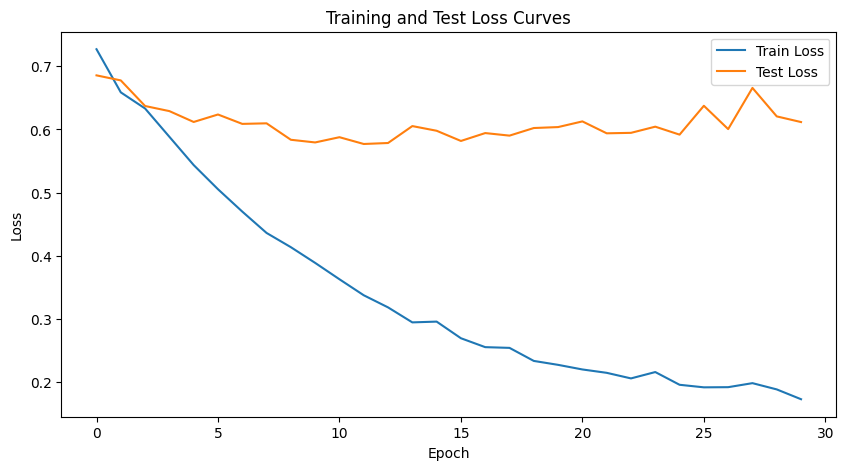

In [137]:
def train_value_network(dataset, num_epochs, learning_rate):
    """
    Train a value network on the provided dataset.
    
    Input:
        dataset: list of (state, action, result) tuples
        num_epochs: number of epochs to train for
        learning_rate: learning rate for gradient descent
    Output:
        model: trained model
    """
    # Make sure dataset is shuffled for better performance
    random.shuffle(dataset)
    
    # Create train/test split (80/20)
    split_idx = int(0.8 * len(dataset))
    train_dataset = dataset[:split_idx]
    test_dataset = dataset[split_idx:]
    
    # Get feature size from sample
    sample_features = get_features(dataset[0][0])
    feature_size = len(sample_features)
    
    # Create model
    model = ValueNetwork(feature_size)
    
    # Specify Loss Function - Mean Squared Error for regression
    loss_function = nn.MSELoss()
    
    # Use Adam optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    batch_size = 32
    
    # Track losses for plotting
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        random.shuffle(train_dataset)  # Shuffle each epoch
        batch_loss = 0.0
        batch_counter = 0
        epoch_loss = 0.0
        
        for data_point in train_dataset:
            state = data_point[0]
            features = get_features(state)
            features_tensor = torch.tensor(features, dtype=torch.float32)
            
            # Label is the game result (outcome from BLACK's perspective)
            # result is the outcome: +1 if black wins, -1 if white wins
            label = torch.tensor([data_point[2]], dtype=torch.float32)
            
            # Get model prediction of value
            prediction = model(features_tensor)
            
            # Compute Loss for data point
            loss = loss_function(prediction, label)
            batch_loss += loss
            epoch_loss += loss.item()
            batch_counter += 1
            
            if batch_counter % batch_size == 0:
                # Call backward to run backward pass and compute gradients
                batch_loss.backward()
                
                # Run gradient descent step with optimizer
                optimizer.step()
                
                # Reset gradient for next batch
                optimizer.zero_grad()
                batch_loss = 0.0
        
        # Process remaining batch if any
        if batch_loss != 0.0:
            batch_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        # Calculate average training loss for epoch
        avg_train_loss = epoch_loss / len(train_dataset)
        train_losses.append(avg_train_loss)
        
        # Evaluate on test set
        test_loss = 0.0
        with torch.no_grad():
            for data_point in test_dataset:
                features = get_features(data_point[0])
                features_tensor = torch.tensor(features, dtype=torch.float32)
                label = torch.tensor([data_point[2]], dtype=torch.float32)
                prediction = model(features_tensor)
                test_loss += loss_function(prediction, label).item()
        
        avg_test_loss = test_loss / len(test_dataset)
        test_losses.append(avg_test_loss)
        
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_epochs), train_losses, label='Train Loss')
    plt.plot(range(num_epochs), test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Curves')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.show()
    
    return model

value_model = train_value_network(dataset_5x5, 30, 1e-3)
save_model("value_model.pt", value_model)

## Comparing Learned Value function against other Agents

In [138]:
class GoProblemLearnedHeuristic(GoProblem):
    def __init__(self, model=None, state=None):
        super().__init__(state=state)
        self.model = model

    def encoding(self, state):
        """
        Get encoding of state (convert state to features)
        
        Input:
            state: GoState to encode into a fixed size list of features
        Output:
            features: list of features
        """
        return get_features(state)

    def heuristic(self, state, player_index):
        """
        Return heuristic (value) of current state
        
        Input:
            state: GoState to encode into a fixed size list of features
            player_index: index of player to evaluate heuristic for
        Output:
            value: heuristic (value) of current state
        """
        if self.model is None:
            return 0
        
        features = self.encoding(state)
        features_tensor = torch.tensor(features, dtype=torch.float32)
        
        with torch.no_grad():
            value = self.model(features_tensor).item()
        
        # Adjust value based on player perspective
        # If evaluating for WHITE (player_index=1), flip the sign
        if player_index == 1:
            value = -value
        
        return value

    def __str__(self) -> str:
        return "Learned Heuristic"


def create_value_agent_from_model(model=None):
    """
    Create agent object from saved model.
    """
    model_path = "value_model.pt"
    
    # Load model if not provided
    if model is None:
        # Calculate feature size from a sample state
        sample_state = dataset_5x5[0][0]
        feature_size = len(get_features(sample_state))
        model = ValueNetwork(feature_size)
        model = load_model(model_path, model)
        model.eval()  # Set to evaluation mode
    
    heuristic_search_problem = GoProblemLearnedHeuristic(model)
    
    # Use GreedyAgent with learned heuristic
    learned_agent = GreedyAgent(heuristic_search_problem)
    
    return learned_agent

# Load the trained model
feature_size = len(get_features(dataset_5x5[0][0]))
value_net = ValueNetwork(feature_size)
value_net = load_model("value_model.pt", value_net)
value_net.eval()

learned_agent = create_value_agent_from_model(value_net)
agent2 = GreedyAgent(GoProblemSimpleHeuristic())
print("Greedy Agent with Simple Heuristic:", agent2)
print("Greedy Agent with Learned Heuristic:", learned_agent)

game_runner = GameRunner()
game_runner.play_tournament(learned_agent, agent2, num_games=100)

Greedy Agent with Simple Heuristic: GreedyAgent + Simple Heuristic
Greedy Agent with Learned Heuristic: GreedyAgent + Learned Heuristic


Playing tournament: 100%|██████████| 50/50 [00:01<00:00, 25.74it/s]

Tournament Results
Games played: 100
GreedyAgent + Learned Heuristic wins: 16 (16.0%)
GreedyAgent + Simple Heuristic wins: 84 (84.0%)
GreedyAgent + Learned Heuristic wins as BLACK: 0
GreedyAgent + Simple Heuristic wins as BLACK: 34
GreedyAgent + Learned Heuristic avg move time: 0.001s
GreedyAgent + Simple Heuristic avg move time: 0.000s
GreedyAgent + Learned Heuristic min time remaining: 27.0s
GreedyAgent + Simple Heuristic min time remaining: 27.0s


TournamentStats(player1_wins=16, player2_wins=84, player1_wins_as_black=0, player2_wins_as_black=34, player1_total_time=np.float64(0.06482741175383866), player2_total_time=np.float64(0.0176192082746909), player1_min_time_remaining=26.989253997802734, player2_min_time_remaining=26.997178077697754, player1_max_move_time=np.float64(0.004000186920166016), player2_max_move_time=np.float64(0.0007269382476806641), games_played=100)